IMPORTAÇÃO DAS BIBLIOTECAS

In [1]:
# Importamos o pandas para trabalhar com tabelas de dados.
import pandas as pd
# Importamos o numpy para operações numéricas.
import numpy as np
# Importamos o módulo os para montar caminhos de arquivos de forma segura.
import os
# Importamos o matplotlib para criar gráficos estáticos.
import matplotlib.pyplot as plt
# Importamos formatadores do matplotlib para personalizar rótulos dos eixos.
import matplotlib.ticker as mticker
# Importamos o seaborn para gráficos estatísticos com estilo mais refinado.
import seaborn as sns
# Importamos o Plotly Express para construir o mapa interativo.
import plotly.express as px
# Importamos warnings para controlar mensagens de aviso durante a execução.
import warnings
# Importamos unicodedata para normalizar strings, útil para lidar com acentos e caracteres especiais.
import unicodedata

LEITURA DOS DADOS

In [2]:
# Ler a planilha tratada que criei
tabelas_descritivas_df = pd.read_excel("analise_descritiva_psicoestimulantes.xlsx")
display(tabelas_descritivas_df)
print("Número de linhas e colunas:", tabelas_descritivas_df.shape)

# Tranformar todas as linhas em minúsculas e sem acentos
def remover_acentos(texto):
    if pd.isna(texto):
        return pd.NA
    
    texto = str(texto)
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        letra for letra in texto
        if not unicodedata.combining(letra)
    )
    return texto

def normalizar_texto(valor):
    if pd.isna(valor):
        return pd.NA
    
    valor = str(valor).strip().lower()
    valor = remover_acentos(valor)
    
    return valor

# Colunas que NÃO quero normalizar como texto
colunas_nao_normalizar = [
    "identificacao_notificacao",
    "n_linhas_mesma_notificacao",
    "idade_no_incidente",
    "data_inicio_uso",
    "data_inclusao_sistema",
    "data_inicio_eam"
]

# Selecionar apenas colunas de texto
colunas_texto = tabelas_descritivas_df.select_dtypes(include=["object", "string"]).columns

# Tirar da lista as colunas que não quero mexer
colunas_texto = [
    coluna for coluna in colunas_texto
    if coluna not in colunas_nao_normalizar
]

# Aplicar normalização
for coluna in colunas_texto:
    tabelas_descritivas_df[coluna] = tabelas_descritivas_df[coluna].apply(normalizar_texto)

# Transformar n/a em dados ausentes de fato
tabelas_descritivas_df = tabelas_descritivas_df.replace(
    ["N/A", "n/a", "-", "", "nan", "NaN", "None", "none"],
    pd.NA)


,identificacao_notificacao,n_linhas_mesma_notificacao,principio_ativo_interesse,principios_ativos_whodrug,sexo,idade_momento_reacao,posologia,dose,data_inicio_uso,indicacao_terapeutica,data_inclusao_sistema,notificador,data_inicio_eam,grave_y,gravidade_y,pt,soc,desfecho_y,sinal_ror,sinal_prr
0,BR-ANVISA-300041842,1,metilfenidato,methylphenidate hydrochloride,Desconhecido,NaN,NaN,NaN,NaN,NaN,20210201,Consumidor ou outro não profissional de saúde,NaN,Sim,Incapacidade persistente ou significativa,distúrbio da fala,Distúrbios do sistema nervoso,Desconhecido,Falso,Falso
1,BR-ANVISA-300038438,6,metilfenidato,methylphenidate hydrochloride,Masculino,8 ano,"30 mg, uma vez ao dia (uma cápsula) (iniciou h...",30 milligram (mg),NaN,Transtorno de déficit de atenção e hiperatividade,20210113,Outro profissional de saúde,2019,Sim,Outro efeito clinicamente significativo,transtorno do espectro autista,Distúrbios psiquiátricos,Desconhecido,Verdadeiro,Verdadeiro
2,BR-ANVISA-300038438,6,metilfenidato,methylphenidate hydrochloride,Masculino,8 ano,"20 mg, uma vez ao dia (uma cápsula) (iniciou h...",20 milligram (mg),NaN,Transtorno de déficit de atenção e hiperatividade,20210113,Outro profissional de saúde,2019,Sim,Outro efeito clinicamente significativo,transtorno do espectro autista,Distúrbios psiquiátricos,Desconhecido,Verdadeiro,Verdadeiro
3,BR-ANVISA-300038438,6,metilfenidato,methylphenidate hydrochloride,Masculino,8 ano,"10 mg, uma vez ao dia (uma cápsula) (iniciou h...",10 milligram (mg),NaN,Transtorno de déficit de atenção e hiperatividade,20210113,Outro profissional de saúde,2019,Sim,Outro efeito clinicamente significativo,transtorno do espectro autista,Distúrbios psiquiátricos,Desconhecido,Verdadeiro,Verdadeiro
4,BR-ANVISA-300038438,6,metilfenidato,methylphenidate hydrochloride,Masculino,8 ano,"30 mg, uma vez ao dia (uma cápsula) (iniciou h...",30 milligram (mg),NaN,Transtorno de déficit de atenção e hiperatividade,20210113,Outro profissional de saúde,2019,Sim,"Incapacidade persistente ou significativa, Out...",incapacidade intelectual,Distúrbios do sistema nervoso,Não Recuperado/Não Resolvido/Em andamento,Falso,Falso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3441,BR-ANVISA-300315648,168,metilfenidato,methylphenidate,Feminino,38 ano,NaN,18 milligram (mg),20250104.0,Transtorno de déficit de atenção-hiperatividade,20250131,Consumidor ou outro não profissional de saúde,20240910,Sim,Outro efeito clinicamente significativo,alucinação,Distúrbios psiquiátricos,Não Recuperado/Não Resolvido/Em andamento,Verdadeiro,Verdadeiro
3442,BR-ANVISA-300315648,168,metilfenidato,methylphenidate,Feminino,38 ano,à tarde,36 milligram (mg),20240927.0,Transtorno de déficit de atenção-hiperatividade,20250131,Consumidor ou outro não profissional de saúde,20240910,Sim,Outro efeito clinicamente significativo,alucinação,Distúrbios psiquiátricos,Não Recuperado/Não Resolvido/Em andamento,Verdadeiro,Verdadeiro
3443,BR-ANVISA-300315648,168,metilfenidato,methylphenidate,Feminino,38 ano,PELA MANHÃ,54 milligram (mg),20240927.0,Transtorno de déficit de atenção-hiperatividade,20250131,Consumidor ou outro não profissional de saúde,20240910,Sim,Outro efeito clinicamente significativo,alucinação,Distúrbios psiquiátricos,Não Recuperado/Não Resolvido/Em andamento,Verdadeiro,Verdadeiro
3444,BR-ANVISA-300315648,168,metilfenidato,methylphenidate,Feminino,38 ano,PELA MANHÃ,54 milliampere (mA),202409.0,Transtorno de déficit de atenção-hiperatividade,20250131,Consumidor ou outro não profissional de saúde,20240910,Sim,Outro efeito clinicamente significativo,alucinação,Distúrbios psiquiátricos,Não Recuperado/Não Resolvido/Em andamento,Verdadeiro,Verdadeiro


Número de linhas e colunas: (3446, 20)


COLUNAS E TIPOS DELAS

In [3]:
# Quero ver quais colunas tenho e como elas aparecem para o python
print(tabelas_descritivas_df.columns.tolist())
display(tabelas_descritivas_df.dtypes)

['identificacao_notificacao', 'n_linhas_mesma_notificacao', 'principio_ativo_interesse', 'principios_ativos_whodrug', 'sexo', 'idade_momento_reacao', 'posologia', 'dose', 'data_inicio_uso', 'indicacao_terapeutica', 'data_inclusao_sistema', 'notificador', 'data_inicio_eam', 'grave_y', 'gravidade_y', 'pt', 'soc', 'desfecho_y', 'sinal_ror', 'sinal_prr']


identificacao_notificacao      object
n_linhas_mesma_notificacao      int64
principio_ativo_interesse      object
principios_ativos_whodrug      object
sexo                           object
idade_momento_reacao           object
posologia                      object
dose                           object
data_inicio_uso               float64
indicacao_terapeutica          object
data_inclusao_sistema           int64
notificador                    object
data_inicio_eam                object
grave_y                        object
gravidade_y                    object
pt                             object
soc                            object
desfecho_y                     object
sinal_ror                      object
sinal_prr                      object
dtype: object

TRATAMENTO DAS COLUNAS

In [4]:
# Transformar idade em variável numérica, para poder fazer análises estatísticas
tabelas_descritivas_df["idade_momento_reacao_num"] = (
    tabelas_descritivas_df["idade_momento_reacao"]
    .astype("string")
    .str.extract(r"(\d+)")
    .astype(float))

# Confirmar datas em formato brasileiro
colunas_data = [
    "data_inicio_uso",
    "data_inclusao_sistema",
    "data_inicio_eam"
]

for coluna in colunas_data:
    if coluna in tabelas_descritivas_df.columns:
        tabelas_descritivas_df[coluna] = pd.to_datetime(
            tabelas_descritivas_df[coluna],
            errors="coerce",
            dayfirst=True
        )

display(tabelas_descritivas_df.dtypes)

identificacao_notificacao             object
n_linhas_mesma_notificacao             int64
principio_ativo_interesse             object
principios_ativos_whodrug             object
sexo                                  object
idade_momento_reacao                  object
posologia                             object
dose                                  object
data_inicio_uso               datetime64[ns]
indicacao_terapeutica                 object
data_inclusao_sistema         datetime64[ns]
notificador                           object
data_inicio_eam               datetime64[ns]
grave_y                               object
gravidade_y                           object
pt                                    object
soc                                   object
desfecho_y                            object
sinal_ror                             object
sinal_prr                             object
idade_momento_reacao_num             float64
dtype: object

CONFERÊNCIA SE PARA UM MESMO PT HÁ MAIS DE UM SOC DIFERENTE

In [5]:
# Criei cópia só com as colunas necessárias
conferencia_pt_soc_df = tabelas_descritivas_df[
    ["identificacao_notificacao", "pt", "soc", "principio_ativo_interesse"]
].copy()

# Removi linhas com PT ou SOC ausentes
conferencia_pt_soc_df = conferencia_pt_soc_df.dropna(
    subset=["pt", "soc"])

# Conferência

conferencia_pt_soc_df = tabelas_descritivas_df[
    ["identificacao_notificacao", "pt", "soc", "principio_ativo_interesse"] # Criei cópia só com as colunas necessárias
].copy()

conferencia_pt_soc_df = conferencia_pt_soc_df.dropna( # Removi linhas com PT ou SOC ausentes
    subset=["pt", "soc"])

tabela_conferencia_pt_soc_df = (
    conferencia_pt_soc_df
    .groupby("pt") # Agrupei por PT
    .agg(
        n_socs_diferentes=("soc", "nunique"), # Contar quantos SOCs diferentes cada PT tem
        socs_encontrados=("soc", lambda x: "; ".join(sorted(x.dropna().unique()))), # Listar os SOCs encontrados para cada PT
        n_linhas=("soc", "size"),
        n_notificacoes_unicas=("identificacao_notificacao", "nunique") # Contar quantas notificações únicas cada PT tem
    )
    .reset_index())

pt_com_mais_de_um_soc_df = (
    tabela_conferencia_pt_soc_df[
        tabela_conferencia_pt_soc_df["n_socs_diferentes"] > 1 # Filtrar apenas PTs que têm mais de um SOC diferente
    ]
    .sort_values("n_socs_diferentes", ascending=False))

print("PTs associados a mais de um SOC diferente:")
display(pt_com_mais_de_um_soc_df)

PTs associados a mais de um SOC diferente:


,pt,n_socs_diferentes,socs_encontrados,n_linhas,n_notificacoes_unicas


FAZER O DESCRIBE PARA TER UMA IDEIA GERAL

In [6]:
# Describe geral
describe_geral_df = tabelas_descritivas_df.describe(include="all")

describe_geral_df = describe_geral_df.rename( # index para deixar o describe mais amigável
    index={
        "count": "Quantidade",
        "unique": "Notificações diferentes",
        "top": "Mais notificado",
        "freq": "Frequência do mais notificado",
        "mean": "Média",
        "std": "Desvio padrão",
        "min": "Mínimo",
        "25%": "1º Quartil",
        "50%": "2º Quartil (Mediana)",
        "75%": "3º Quartil",
        "max": "Máximo"
    }
)

print("GERAL")
display(describe_geral_df)

# Describe só dos numéricos
describe_numericas_df = tabelas_descritivas_df.describe().transpose()
describe_numericas_df = describe_numericas_df.rename(
    index={
        "count": "Quantidade",
        "mean": "Média",
        "std": "Desvio padrão",
        "min": "Mínimo",
        "25%": "1º Quartil",
        "50%": "2º Quartil (Mediana)",
        "75%": "3º Quartil",
        "max": "Máximo"
    }
)
print("NUMÉRICAS")
display(describe_numericas_df)

# Describe só dos categóricos
describe_categoricas_df = tabelas_descritivas_df.describe(include=["object", "string"])
print("CATEGÓRICAS")
display(describe_categoricas_df)

GERAL


,identificacao_notificacao,n_linhas_mesma_notificacao,principio_ativo_interesse,principios_ativos_whodrug,sexo,idade_momento_reacao,posologia,dose,data_inicio_uso,indicacao_terapeutica,...,notificador,data_inicio_eam,grave_y,gravidade_y,pt,soc,desfecho_y,sinal_ror,sinal_prr,idade_momento_reacao_num
Quantidade,3446,3446.000000,3446,3446,3327,1186,2318,1795,1037,3269,...,3442,243,3322,825,3446,3446,3357,3446,3446,1186.000000
Notificações diferentes,415,NaN,2,4,3,47,196,26,NaN,88,...,4,NaN,2,17,540,27,6,2,2,NaN
Mais notificado,BR-ANVISA-300315648,NaN,lisdexanfetamina,mesilato de lisdexanfetamina,masculino,38 ano,dose e frequencia nao especificadas,10 milligram (mg),NaN,transtorno de deficit de atencao-hiperatividade,...,consumidor ou outro nao profissional de saude,NaN,nao,outro efeito clinicamente significativo,medicamento ineficaz,disturbios psiquiatricos,desconhecido,verdadeiro,verdadeiro,NaN
Frequência do mais notificado,168,NaN,1910,1910,1760,173,317,318,NaN,1170,...,3056,NaN,2497,661,237,897,2448,2164,2164,NaN
Média,NaN,29.372606,NaN,NaN,NaN,NaN,NaN,NaN,1970-01-01 00:00:00.011395493,NaN,...,NaN,2021-01-06 19:27:24.444444416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.191400
Mínimo,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1970-01-01 00:00:00.000002014,NaN,...,NaN,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
1º Quartil,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,1970-01-01 00:00:00.000202108,NaN,...,NaN,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.000000
2º Quartil (Mediana),NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,1970-01-01 00:00:00.020221014,NaN,...,NaN,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.000000
3º Quartil,NaN,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,1970-01-01 00:00:00.020240927,NaN,...,NaN,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.000000
Máximo,NaN,168.000000,NaN,NaN,NaN,NaN,NaN,NaN,1970-01-01 00:00:00.020251127,NaN,...,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.000000


NUMÉRICAS


,count,mean,min,25%,50%,75%,max,std
n_linhas_mesma_notificacao,3446.0,29.372606,1.0,7.0,18.0,39.0,168.0,36.030883
data_inicio_uso,1037,1970-01-01 00:00:00.011395493,1970-01-01 00:00:00.000002014,1970-01-01 00:00:00.000202108,1970-01-01 00:00:00.020221014,1970-01-01 00:00:00.020240927,1970-01-01 00:00:00.020251127,NaN
data_inclusao_sistema,3446,1970-01-01 00:00:00.020236670,1970-01-01 00:00:00.020190131,1970-01-01 00:00:00.020230803,1970-01-01 00:00:00.020240318,1970-01-01 00:00:00.020241127,1970-01-01 00:00:00.020251207,NaN
data_inicio_eam,243,2021-01-06 19:27:24.444444416,2016-01-01 00:00:00,2021-01-01 00:00:00,2021-01-01 00:00:00,2021-01-01 00:00:00,2025-01-01 00:00:00,NaN
idade_momento_reacao_num,1186.0,32.1914,5.0,24.0,32.0,39.0,72.0,11.938293


CATEGÓRICAS


,identificacao_notificacao,principio_ativo_interesse,principios_ativos_whodrug,sexo,idade_momento_reacao,posologia,dose,indicacao_terapeutica,notificador,grave_y,gravidade_y,pt,soc,desfecho_y,sinal_ror,sinal_prr
count,3446,3446,3446,3327,1186,2318,1795,3269,3442,3322,825,3446,3446,3357,3446,3446
unique,415,2,4,3,47,196,26,88,4,2,17,540,27,6,2,2
top,BR-ANVISA-300315648,lisdexanfetamina,mesilato de lisdexanfetamina,masculino,38 ano,dose e frequencia nao especificadas,10 milligram (mg),transtorno de deficit de atencao-hiperatividade,consumidor ou outro nao profissional de saude,nao,outro efeito clinicamente significativo,medicamento ineficaz,disturbios psiquiatricos,desconhecido,verdadeiro,verdadeiro
freq,168,1910,1910,1760,173,317,318,1170,3056,2497,661,237,897,2448,2164,2164


OBSERVAR DADO A DADO

ANTES DE QUALQUER COISA FIZ UMA FUNÇÃO PARA CATEGÓRICAS E UMA FUNÇÃO PARA UM GRÁFICO DE PIZZA

In [17]:
# CONFERÊNCIA: verificar se alguma notificação possui os dois medicamentos

notificacoes_dois_medicamentos = (
    tabelas_descritivas_df
    .groupby("identificacao_notificacao")["principio_ativo_interesse"]
    .nunique()
)

print(
    "Número de notificações associadas aos dois medicamentos:",
    (notificacoes_dois_medicamentos == 2).sum())

Número de notificações associadas aos dois medicamentos: 8


In [ ]:
# Descobrir quais desses 8 são
ids_dois_medicamentos = notificacoes_dois_medicamentos[
    notificacoes_dois_medicamentos == 2
].index

print(ids_dois_medicamentos)

Index(['BR-ANVISA-300185929', 'BR-ANVISA-300292063', 'BR-ANVISA-300292171',
       'BR-ANVISA-300292191', 'BR-ANVISA-300304951', 'BR-ANVISA-300340193',
       'BR-ANVISA-300397813', 'BR-ANVISA-300398694'],
      dtype='object', name='identificacao_notificacao')


In [19]:
tabelas_descritivas_df[
    tabelas_descritivas_df["identificacao_notificacao"].isin(ids_dois_medicamentos)
][
    ["identificacao_notificacao", "principio_ativo_interesse"]
].drop_duplicates()

,identificacao_notificacao,principio_ativo_interesse
1404,BR-ANVISA-300397813,lisdexanfetamina
1405,BR-ANVISA-300397813,metilfenidato
1712,BR-ANVISA-300185929,metilfenidato
1713,BR-ANVISA-300185929,lisdexanfetamina
2526,BR-ANVISA-300292191,metilfenidato
2527,BR-ANVISA-300292191,lisdexanfetamina
2536,BR-ANVISA-300292063,metilfenidato
2537,BR-ANVISA-300292063,lisdexanfetamina
2548,BR-ANVISA-300292171,metilfenidato
2549,BR-ANVISA-300292171,lisdexanfetamina


In [20]:
(tabelas_descritivas_df[
        tabelas_descritivas_df["identificacao_notificacao"].isin(ids_dois_medicamentos)
    ]
    .groupby(["identificacao_notificacao", "principio_ativo_interesse"])
    .size()
    .reset_index(name="n_linhas"))

,identificacao_notificacao,principio_ativo_interesse,n_linhas
0,BR-ANVISA-300185929,lisdexanfetamina,11
1,BR-ANVISA-300185929,metilfenidato,11
2,BR-ANVISA-300292063,lisdexanfetamina,6
3,BR-ANVISA-300292063,metilfenidato,6
4,BR-ANVISA-300292171,lisdexanfetamina,10
5,BR-ANVISA-300292171,metilfenidato,5
6,BR-ANVISA-300292191,lisdexanfetamina,5
7,BR-ANVISA-300292191,metilfenidato,5
8,BR-ANVISA-300304951,lisdexanfetamina,45
9,BR-ANVISA-300304951,metilfenidato,15


In [21]:
# Criar base com notificações únicas para não inflar porcentagens
base_notificacoes_unicas = (
    tabelas_descritivas_df
    .drop_duplicates(
        subset=["identificacao_notificacao", "principio_ativo_interesse"]
    )
    .copy())

In [22]:
# Criei uma função para as variáveis categóricas com n e % separada por medicamento

def tabela_dados_categorica(df, variavel, grupo="principio_ativo_interesse"):

    # 1. Copiar só as colunas necessárias
    base = df[[grupo, variavel]].copy()

    # 2. Transformar vazios em N/A para aparecerem na tabela
    base[grupo] = base[grupo].fillna("N/A")
    base[variavel] = base[variavel].fillna("N/A")

    # 3. Contar n por medicamento
    tabela_n = pd.crosstab(
        base[variavel],
        base[grupo],
        dropna=False
    )

    # 4. Calcular % dentro de cada medicamento
    tabela_percentual = pd.crosstab(
        base[variavel],
        base[grupo],
        normalize="columns",
        dropna=False
    ) * 100

    # 5. Ordenar as categorias pela frequência total, do maior para o menor
    ordem = base[variavel].value_counts(dropna=False).index

    tabela_n = tabela_n.reindex(ordem)
    tabela_percentual = tabela_percentual.reindex(ordem)

    # 6. Criar tabela final
    tabela_dados_final = pd.DataFrame(index=tabela_n.index)

    # 7. Coluna Total geral
    n_total = base[variavel].value_counts(dropna=False).reindex(tabela_n.index, fill_value=0)
    pct_total = n_total / n_total.sum() * 100

    tabela_dados_final["Total"] = [
        f"{int(n_total[categoria])} ({pct_total[categoria]:.1f}%)"
        for categoria in tabela_dados_final.index
    ]

    # 8. Colunas por medicamento
    for medicamento in tabela_n.columns:
        tabela_dados_final[medicamento] = [
            f"{int(tabela_n.loc[categoria, medicamento])} ({tabela_percentual.loc[categoria, medicamento]:.1f}%)"
            for categoria in tabela_dados_final.index
        ]

    # 9. Adicionar linha Total no final
    linha_total = {"Total": f"{len(base)} (100.0%)"}

    for medicamento in tabela_n.columns:
        linha_total[medicamento] = f"{int(tabela_n[medicamento].sum())} (100.0%)"

    tabela_dados_final.loc["Total"] = linha_total

    # 10. Transformar o índice em coluna normal
    tabela_dados_final = tabela_dados_final.reset_index()
    tabela_dados_final = tabela_dados_final.rename(columns={"index": variavel})

    return tabela_dados_final

In [9]:
# Função para gráfico de pizza
def grafico_pizza_por_medicamento(
    df,
    variavel,
    grupo="principio_ativo_interesse",
    medicamentos=["metilfenidato", "lisdexanfetamina"],
    top_n=8
):
    for medicamento in medicamentos:

        # 1. Filtrar só o medicamento atual
        base_medicamento = df[df[grupo] == medicamento].copy()

        # 2. Contar categorias da variável
        contagem = (
            base_medicamento[variavel]
            .fillna("N/A")
            .value_counts(dropna=False)
        )

        # 3. Se tiver categorias demais, juntar o resto em "outros"
        if len(contagem) > top_n:
            principais = contagem.head(top_n)
            outros = contagem.iloc[top_n:].sum()

            contagem = pd.concat([
                principais,
                pd.Series({"outros": outros})
            ])

        # 4. Criar gráfico de pizza
        plt.figure(figsize=(7, 7))

        plt.pie(
            contagem,
            labels=contagem.index,
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title(f"{variavel} - {medicamento}")
        plt.axis("equal")

        plt.show()

In [10]:
# Função para salvar pizza como imagem para o excel
def salvar_pizzas_por_medicamento(
    df,
    variavel,
    pasta_graficos="graficos_temporarios",
    grupo="principio_ativo_interesse",
    medicamentos=["metilfenidato", "lisdexanfetamina"],
    top_n=6
):
    os.makedirs(pasta_graficos, exist_ok=True)

    caminhos_imagens = []

    for medicamento in medicamentos:
        base_medicamento = df[df[grupo] == medicamento].copy()

        contagem = (
            base_medicamento[variavel]
            .fillna("N/A")
            .value_counts(dropna=False)
        )

        if len(contagem) > top_n:
            principais = contagem.head(top_n)
            outros = contagem.iloc[top_n:].sum()

            contagem = pd.concat([
                principais,
                pd.Series({"outros": outros})
            ])

        plt.figure(figsize=(7, 7))

        plt.pie(
            contagem,
            labels=contagem.index,
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title(f"{variavel} - {medicamento}")
        plt.axis("equal")

        nome_arquivo = f"{variavel}_{medicamento}.png".replace("/", "_")
        caminho_imagem = os.path.join(pasta_graficos, nome_arquivo)

        plt.savefig(caminho_imagem, dpi=300, bbox_inches="tight")
        plt.close()

        caminhos_imagens.append(caminho_imagem)

    return caminhos_imagens

PARTE 1 - CARACTERÍSTICAS SOCIODEMOGRÁFICAS

Sexos notificados:


,sexo,Total,lisdexanfetamina,metilfenidato
0,masculino,224 (53.0%),103 (45.8%),121 (61.1%)
1,feminino,177 (41.8%),107 (47.6%),70 (35.4%)
2,N/A,20 (4.7%),15 (6.7%),5 (2.5%)
3,desconhecido,2 (0.5%),0 (0.0%),2 (1.0%)
4,Total,423 (100.0%),225 (100.0%),198 (100.0%)


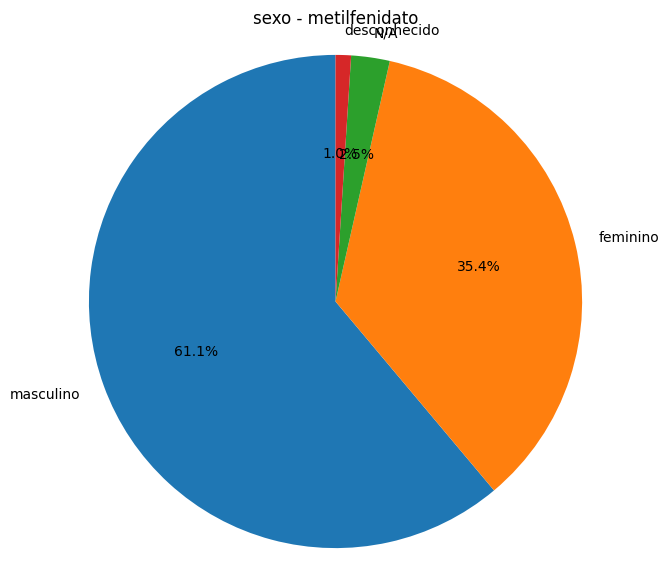

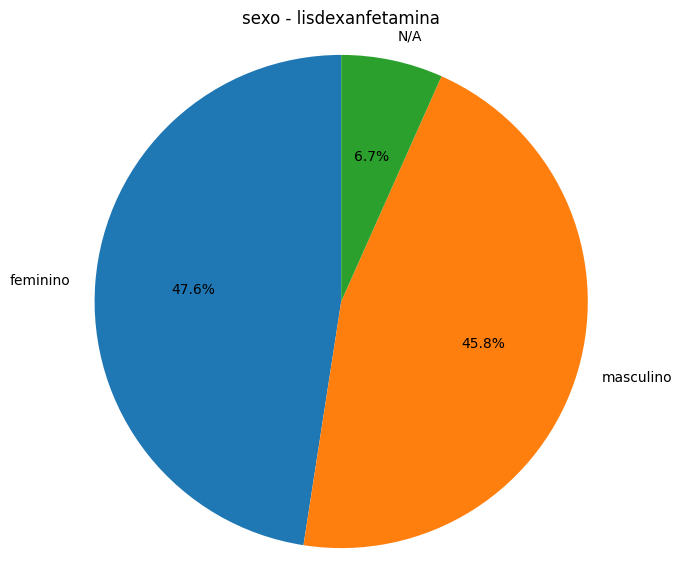

In [23]:
# Sexos notificados

tabela_sexo_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="sexo")

print("Sexos notificados:")
display(tabela_sexo_df)
grafico_pizza_por_medicamento(
    base_notificacoes_unicas,
    variavel="sexo")

,principio_ativo_interesse,n,media,desvio_padrao,mediana,minimo,maximo
0,Total,167,28.30,12.46,27.0,5.0,72.0
1,lisdexanfetamina,99,30.57,10.76,29.0,5.0,72.0
2,metilfenidato,68,25.00,14.03,24.0,6.0,65.0


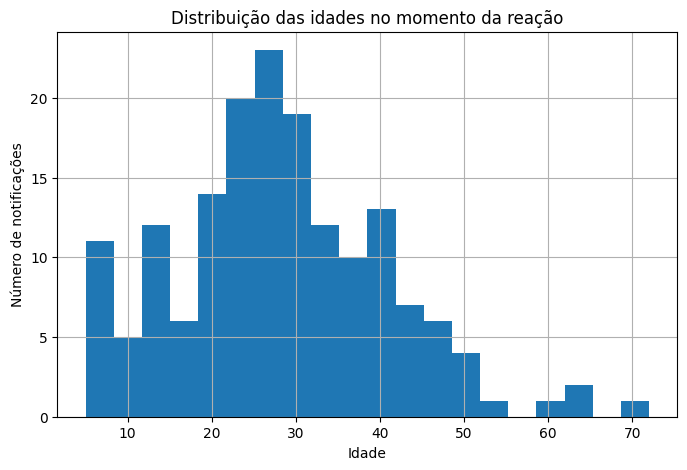

In [24]:
# Idades no momento da reação

tabela_idade_df = (base_notificacoes_unicas.groupby("principio_ativo_interesse")["idade_momento_reacao_num"].agg(
        n="count",
        media="mean",
        desvio_padrao="std",
        mediana="median",
        minimo="min",
        maximo="max")
    .round(2)
    .reset_index())

# Adicionar total geral
idade_total_df = pd.DataFrame({
    "principio_ativo_interesse": ["Total"],
    "n": [base_notificacoes_unicas["idade_momento_reacao_num"].count()],
    "media": [base_notificacoes_unicas["idade_momento_reacao_num"].mean()],
    "desvio_padrao": [base_notificacoes_unicas["idade_momento_reacao_num"].std()],
    "mediana": [base_notificacoes_unicas["idade_momento_reacao_num"].median()],
    "minimo": [base_notificacoes_unicas["idade_momento_reacao_num"].min()],
    "maximo": [base_notificacoes_unicas["idade_momento_reacao_num"].max()]
}).round(2)

# Juntar total + medicamentos
tabela_idade_df = pd.concat(
    [idade_total_df, tabela_idade_df],
    ignore_index=True)

display(tabela_idade_df)

# Fiz também um histograma
plt.figure(figsize=(8, 5))
base_notificacoes_unicas["idade_momento_reacao_num"].dropna().hist(bins=20)

plt.title("Distribuição das idades no momento da reação")
plt.xlabel("Idade")
plt.ylabel("Número de notificações")

plt.show()

PARTE 2 - CARACTERÍSTICAS DO MEDICAMENTO SUSPEITO

In [25]:
# Princípios ativos notificados

tabela_principios_ativos_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="principios_ativos_whodrug")

display(tabela_principios_ativos_df)

,principios_ativos_whodrug,Total,lisdexanfetamina,metilfenidato
0,mesilato de lisdexanfetamina,225 (53.2%),225 (100.0%),0 (0.0%)
1,cloridrato de metilfenidato,106 (25.1%),0 (0.0%),106 (53.5%)
2,methylphenidate hydrochloride,68 (16.1%),0 (0.0%),68 (34.3%)
3,methylphenidate,24 (5.7%),0 (0.0%),24 (12.1%)
4,Total,423 (100.0%),225 (100.0%),198 (100.0%)


In [26]:
# Posologia e dose
# VER COMO PADRONIZAR AS NOTIFICAÇÕES DE UM JEITO BOM (SEM ESPAÇO ENTRE NÚMERO E UNIDADE, POR EXEMPLO)

tabela_posologia_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="posologia")

print("Posologia:")
display(tabela_posologia_df)

tabela_dose_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="dose")

print("Doses:")
display(tabela_dose_df)

Posologia:


,posologia,Total,lisdexanfetamina,metilfenidato
0,N/A,127 (30.0%),74 (32.9%),53 (26.8%)
1,dose e frequencia nao especificadas,33 (7.8%),29 (12.9%),4 (2.0%)
2,dose e frequencia desconhecidas,26 (6.1%),24 (10.7%),2 (1.0%)
3,10 mg,25 (5.9%),0 (0.0%),25 (12.6%)
4,unk,12 (2.8%),0 (0.0%),12 (6.1%)
...,...,...,...,...
157,"dose desconhecida, frequencia de uma vez ao dia",1 (0.2%),1 (0.4%),0 (0.0%)
158,1x/2 semanas,1 (0.2%),0 (0.0%),1 (0.5%)
159,"30mg, 1x ao dia",1 (0.2%),1 (0.4%),0 (0.0%)
160,18mg por 30 dias e 36mg por 21 dias,1 (0.2%),0 (0.0%),1 (0.5%)


Doses:


,dose,Total,lisdexanfetamina,metilfenidato
0,N/A,263 (62.2%),161 (71.6%),102 (51.5%)
1,10 milligram (mg),45 (10.6%),1 (0.4%),44 (22.2%)
2,1 dosage form ({df}),33 (7.8%),29 (12.9%),4 (2.0%)
3,20 milligram (mg),14 (3.3%),0 (0.0%),14 (7.1%)
4,30 milligram (mg),13 (3.1%),9 (4.0%),4 (2.0%)
5,70 milligram (mg),11 (2.6%),11 (4.9%),0 (0.0%)
6,2 dosage form ({df}),9 (2.1%),5 (2.2%),4 (2.0%)
7,50 milligram (mg),6 (1.4%),5 (2.2%),1 (0.5%)
8,54 milligram (mg),6 (1.4%),0 (0.0%),6 (3.0%)
9,18 milligram (mg),6 (1.4%),0 (0.0%),6 (3.0%)


In [27]:
# Data do início do uso do medicamento # VER O QUE EU FAÇO COM ESSES NUMEROS ESQUISITOS

coluna_data_inicio_uso = base_notificacoes_unicas["data_inicio_uso"].value_counts(dropna=False)
print("Datas de início do uso do medicamento:")
display(coluna_data_inicio_uso)

Datas de início do uso do medicamento:


data_inicio_uso
NaT                              290
1970-01-01 00:00:00.000002018      5
1970-01-01 00:00:00.000002019      3
1970-01-01 00:00:00.000002021      2
1970-01-01 00:00:00.020241108      2
                                ... 
1970-01-01 00:00:00.000202311      1
1970-01-01 00:00:00.000202404      1
1970-01-01 00:00:00.020251007      1
1970-01-01 00:00:00.000002023      1
1970-01-01 00:00:00.020250105      1
Name: count, Length: 116, dtype: int64

In [28]:
# Indicação terapêutica
tabela_indicacao_terapeutica_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="indicacao_terapeutica")

print("Indicações terapêuticas:")
display(tabela_indicacao_terapeutica_df)

Indicações terapêuticas:


,indicacao_terapeutica,Total,lisdexanfetamina,metilfenidato
0,transtorno de deficit de atencao-hiperatividade,94 (22.2%),70 (31.1%),24 (12.1%)
1,uso de medicamento para indicacao desconhecida,67 (15.8%),45 (20.0%),22 (11.1%)
2,produto usado para indicacao desconhecida,63 (14.9%),13 (5.8%),50 (25.3%)
3,tdah,56 (13.2%),26 (11.6%),30 (15.2%)
4,N/A,29 (6.9%),6 (2.7%),23 (11.6%)
...,...,...,...,...
83,insatisfacao no trabalho,1 (0.2%),1 (0.4%),0 (0.0%)
84,ansiedade,1 (0.2%),1 (0.4%),0 (0.0%)
85,depressao,1 (0.2%),1 (0.4%),0 (0.0%)
86,transtorno de deficit de atencao-hiperatividad...,1 (0.2%),1 (0.4%),0 (0.0%)


PARTE 3 - CARACTERÍSTICAS DAS NOTIFICAÇÕES DOS INCIDENTES

In [29]:
# Identificação da notificação

# Criei uma tabela-resumo geral das identificações
n_linhas_total = len(tabelas_descritivas_df)

n_notificacoes_unicas = (
    tabelas_descritivas_df["identificacao_notificacao"]
    .nunique(dropna=True))

n_linhas_sem_identificacao = (
    tabelas_descritivas_df["identificacao_notificacao"]
    .isna()
    .sum())

tabela_resumo_notificacoes_geral_df = pd.DataFrame({
    "grupo": ["geral", "geral", "geral"],
    "indicador": [
        "n_linhas_na_base",
        "n_notificacoes_unicas",
        "n_linhas_sem_identificacao"
    ],
    "valor": [
        n_linhas_total,
        n_notificacoes_unicas,
        n_linhas_sem_identificacao
    ]
})

display(tabela_resumo_notificacoes_geral_df)

# Criei um resumo por princípio ativo
tabela_resumo_notificacoes_medicamento_df = (
    tabelas_descritivas_df
    .groupby("principio_ativo_interesse")
    .agg(
        n_linhas_na_base=("identificacao_notificacao", "size"),
        n_notificacoes_unicas=("identificacao_notificacao", "nunique"),
        n_linhas_sem_identificacao=("identificacao_notificacao", lambda x: x.isna().sum())
    )
    .reset_index())

display(tabela_resumo_notificacoes_medicamento_df)

# Juntei as duas 
tabela_resumo_notificacoes_medicamento_formatada_df = (
    tabela_resumo_notificacoes_medicamento_df
    .melt(
        id_vars="principio_ativo_interesse",
        var_name="indicador",
        value_name="valor"
    )
    .rename(columns={"principio_ativo_interesse": "grupo"}))

tabela_resumo_notificacoes_df = pd.concat([
        tabela_resumo_notificacoes_geral_df,
        tabela_resumo_notificacoes_medicamento_formatada_df], ignore_index=True)

display(tabela_resumo_notificacoes_df)


,grupo,indicador,valor
0,geral,n_linhas_na_base,3446
1,geral,n_notificacoes_unicas,415
2,geral,n_linhas_sem_identificacao,0


,principio_ativo_interesse,n_linhas_na_base,n_notificacoes_unicas,n_linhas_sem_identificacao
0,lisdexanfetamina,1910,225,0
1,metilfenidato,1536,198,0


,grupo,indicador,valor
0,geral,n_linhas_na_base,3446
1,geral,n_notificacoes_unicas,415
2,geral,n_linhas_sem_identificacao,0
3,lisdexanfetamina,n_linhas_na_base,1910
4,metilfenidato,n_linhas_na_base,1536
5,lisdexanfetamina,n_notificacoes_unicas,225
6,metilfenidato,n_notificacoes_unicas,198
7,lisdexanfetamina,n_linhas_sem_identificacao,0
8,metilfenidato,n_linhas_sem_identificacao,0


In [30]:
# Data da notificação no sistema (data de inclusão no sistema) # VER O QUE FAZER COM OS NUMEROS ESQUISITOS
coluna_data_inclusao_sistema = base_notificacoes_unicas["data_inclusao_sistema"].value_counts(dropna=False)
print("Datas de inclusão no sistema:")
display(coluna_data_inclusao_sistema)

Datas de inclusão no sistema:


data_inclusao_sistema
1970-01-01 00:00:00.020240920    7
1970-01-01 00:00:00.020240203    6
1970-01-01 00:00:00.020240313    4
1970-01-01 00:00:00.020230410    4
1970-01-01 00:00:00.020250512    4
                                ..
1970-01-01 00:00:00.020210818    1
1970-01-01 00:00:00.020210803    1
1970-01-01 00:00:00.020210802    1
1970-01-01 00:00:00.020210719    1
1970-01-01 00:00:00.020210730    1
Name: count, Length: 328, dtype: int64

Tipos de notificador:


,notificador,Total,lisdexanfetamina,metilfenidato
0,consumidor ou outro nao profissional de saude,347 (82.0%),189 (84.0%),158 (79.8%)
1,outro profissional de saude,30 (7.1%),16 (7.1%),14 (7.1%)
2,farmaceutico,24 (5.7%),6 (2.7%),18 (9.1%)
3,medico,19 (4.5%),12 (5.3%),7 (3.5%)
4,N/A,3 (0.7%),2 (0.9%),1 (0.5%)
5,Total,423 (100.0%),225 (100.0%),198 (100.0%)


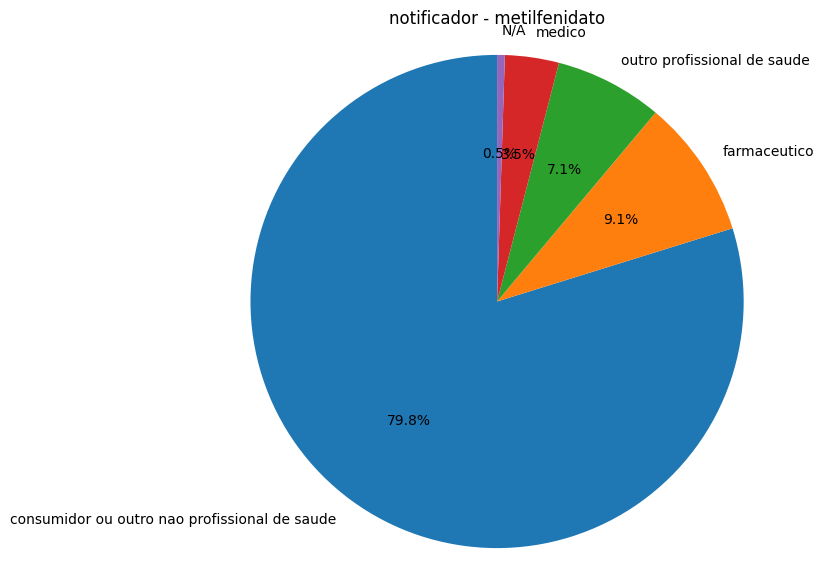

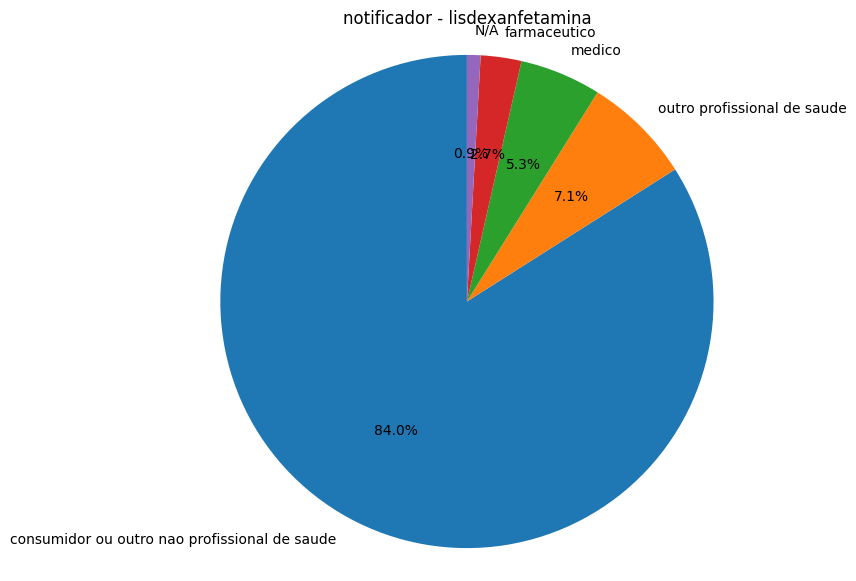

In [31]:
# Tipo de notificador
tabela_tipo_notificador_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="notificador")

print("Tipos de notificador:")
display(tabela_tipo_notificador_df)
grafico_pizza_por_medicamento(
    base_notificacoes_unicas,
    variavel="notificador")

In [42]:
# Qualidade do relato? # Fiz algo superficial só para ter uma noção no final dessa parte

PARTE 4 - SUSPEITA DE INCIDENTES

In [38]:
# Descrição da suspeita do incidente
tabela_descricao_pt_df = tabela_dados_categorica(
    tabelas_descritivas_df,
    variavel="pt")

print("Descrição da suspeita do incidente (PT):")
display(tabela_descricao_pt_df)

tabela_descricao_soc_df = tabela_dados_categorica(
    tabelas_descritivas_df,
    variavel="soc")

print("Descrição da suspeita do incidente (SOC):")
display(tabela_descricao_soc_df)

Descrição da suspeita do incidente (PT):


,pt,Total,lisdexanfetamina,metilfenidato
0,medicamento ineficaz,237 (6.9%),155 (8.1%),82 (5.3%)
1,dependencia de droga ou medicamento,120 (3.5%),79 (4.1%),41 (2.7%)
2,ansiedade,80 (2.3%),47 (2.5%),33 (2.1%)
3,depressao,70 (2.0%),34 (1.8%),36 (2.3%)
4,problema de utilizacao de produto,64 (1.9%),49 (2.6%),15 (1.0%)
...,...,...,...,...
536,impaciencia,1 (0.0%),1 (0.1%),0 (0.0%)
537,secrecao,1 (0.0%),1 (0.1%),0 (0.0%)
538,acne pustulosa,1 (0.0%),1 (0.1%),0 (0.0%)
539,disturbio maxilar,1 (0.0%),1 (0.1%),0 (0.0%)


Descrição da suspeita do incidente (SOC):


,soc,Total,lisdexanfetamina,metilfenidato
0,disturbios psiquiatricos,897 (26.0%),484 (25.3%),413 (26.9%)
1,disturbios gerais e quadros clinicos no local ...,690 (20.0%),405 (21.2%),285 (18.6%)
2,"lesoes, intoxicacoes e complicacoes de procedi...",418 (12.1%),282 (14.8%),136 (8.9%)
3,disturbios do sistema nervoso,378 (11.0%),183 (9.6%),195 (12.7%)
4,problemas relacionados ao produto,199 (5.8%),117 (6.1%),82 (5.3%)
5,investigacoes,126 (3.7%),61 (3.2%),65 (4.2%)
6,disturbios gastrointestinais,126 (3.7%),62 (3.2%),64 (4.2%)
7,circunstancias sociais,97 (2.8%),75 (3.9%),22 (1.4%)
8,disturbios cardiacos,67 (1.9%),39 (2.0%),28 (1.8%)
9,"disturbios respiratorios, toracicos e do media...",63 (1.8%),25 (1.3%),38 (2.5%)


In [32]:
# Data do início do EAM # VER O QUE EU FAÇO COM ESSES NUMEROS ESQUISITOS
coluna_data_inicio_eam = base_notificacoes_unicas["data_inicio_eam"].value_counts(dropna=False)
print("Datas de início do EAM:")
display(coluna_data_inicio_eam)


Datas de início do EAM:


data_inicio_eam
NaT           407
2019-01-01      3
2021-01-01      3
2023-01-01      3
2020-01-01      2
2025-01-01      2
2022-01-01      1
2016-01-01      1
2024-01-01      1
Name: count, dtype: int64

Incidente grave?:


,grave_y,Total,lisdexanfetamina,metilfenidato
0,nao,302 (71.4%),170 (75.6%),132 (66.7%)
1,sim,90 (21.3%),43 (19.1%),47 (23.7%)
2,N/A,31 (7.3%),12 (5.3%),19 (9.6%)
3,Total,423 (100.0%),225 (100.0%),198 (100.0%)


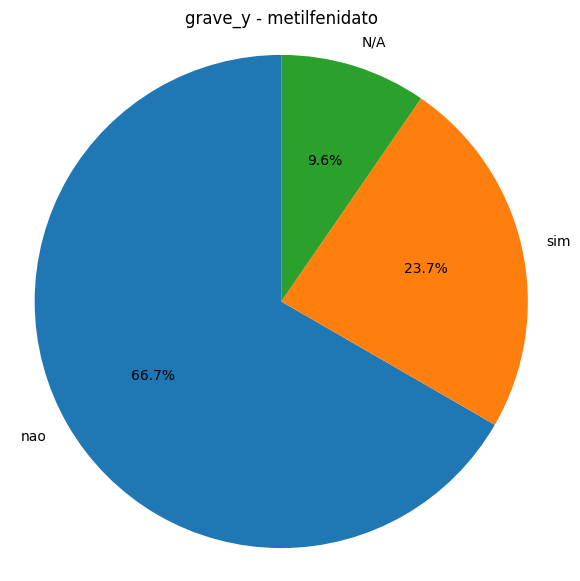

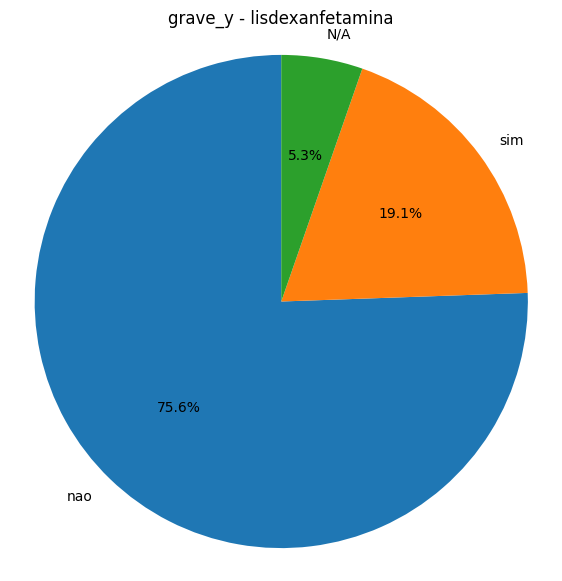

Gravidade da suspeita do incidente:


,gravidade_y,Total,lisdexanfetamina,metilfenidato
0,N/A,333 (78.7%),182 (80.9%),151 (76.3%)
1,outro efeito clinicamente significativo,61 (14.4%),30 (13.3%),31 (15.7%)
2,incapacidade persistente ou significativa,10 (2.4%),5 (2.2%),5 (2.5%)
3,hospitalizacao/prolongamento de hospitalizacao,4 (0.9%),1 (0.4%),3 (1.5%)
4,"incapacidade persistente ou significativa, out...",3 (0.7%),0 (0.0%),3 (1.5%)
5,hospitalizacao/prolongamento de hospitalizacao...,3 (0.7%),3 (1.3%),0 (0.0%)
6,ameaca a vida,3 (0.7%),3 (1.3%),0 (0.0%)
7,resultou em obito,2 (0.5%),0 (0.0%),2 (1.0%)
8,"incapacidade persistente ou significativa, ame...",1 (0.2%),0 (0.0%),1 (0.5%)
9,"ameaca a vida, hospitalizacao/prolongamento de...",1 (0.2%),0 (0.0%),1 (0.5%)


In [33]:
# Gravidade da suspeita do incidente
tabela_grave_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="grave_y")

print("Incidente grave?:")
display(tabela_grave_df)
grafico_pizza_por_medicamento(
    base_notificacoes_unicas,
    variavel="grave_y")

tabela_gravidade_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="gravidade_y")

print("Gravidade da suspeita do incidente:")
display(tabela_gravidade_df)

In [34]:
# Desfecho
tabela_desfecho_df = tabela_dados_categorica(
    base_notificacoes_unicas,
    variavel="desfecho_y")

print("Desfecho da suspeita do incidente:")
display(tabela_desfecho_df)

Desfecho da suspeita do incidente:


,desfecho_y,Total,lisdexanfetamina,metilfenidato
0,desconhecido,281 (66.4%),160 (71.1%),121 (61.1%)
1,recuperado/resolvido,45 (10.6%),19 (8.4%),26 (13.1%)
2,nao recuperado/nao resolvido/em andamento,43 (10.2%),20 (8.9%),23 (11.6%)
3,N/A,36 (8.5%),17 (7.6%),19 (9.6%)
4,em recuperacao/resolvendo,16 (3.8%),9 (4.0%),7 (3.5%)
5,fatal/obito,2 (0.5%),0 (0.0%),2 (1.0%)
6,Total,423 (100.0%),225 (100.0%),198 (100.0%)


Detecção de sinais da suspeita do incidente:


,metodo,deteccao_sinal,Total,lisdexanfetamina,metilfenidato
0,ROR,verdadeiro,2164 (62.8%),1310 (68.6%),854 (55.6%)
1,ROR,falso,1282 (37.2%),600 (31.4%),682 (44.4%)
2,ROR,Total,3446 (100.0%),1910 (100.0%),1536 (100.0%)
3,PRR,verdadeiro,2164 (62.8%),1310 (68.6%),854 (55.6%)
4,PRR,falso,1282 (37.2%),600 (31.4%),682 (44.4%)
5,PRR,Total,3446 (100.0%),1910 (100.0%),1536 (100.0%)


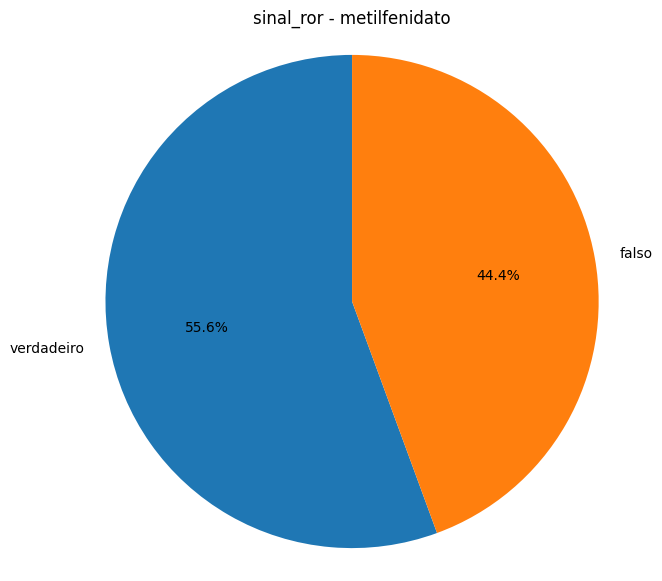

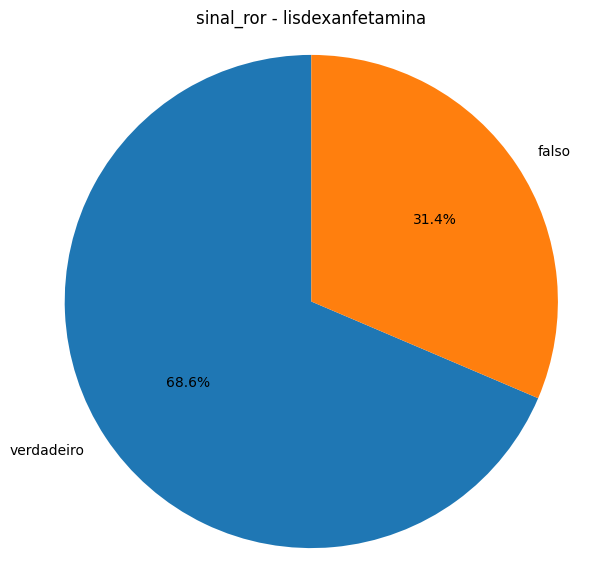

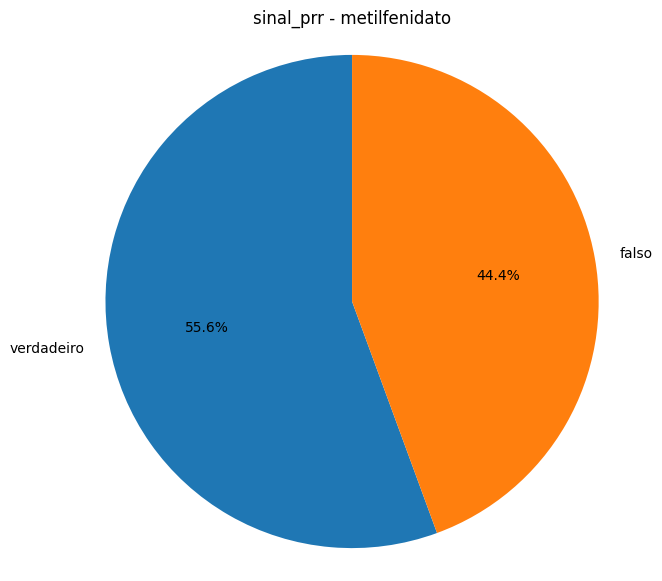

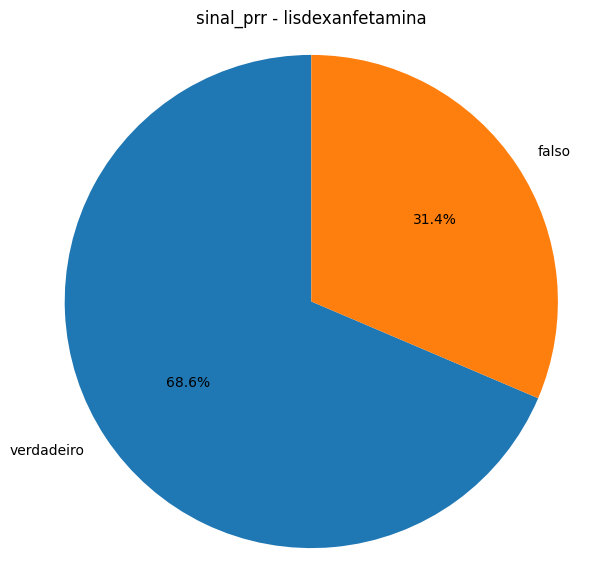

In [35]:
# Detecção de sinais -> Queria fazer na mesma tabela:

# Tabela do sinal ROR
tabela_sinal_ror_df = tabela_dados_categorica(
    tabelas_descritivas_df,
    variavel="sinal_ror")

tabela_sinal_ror_df.insert(0, "metodo", "ROR")
tabela_sinal_ror_df = tabela_sinal_ror_df.rename(
    columns={"sinal_ror": "deteccao_sinal"})

# Tabela do sinal PRR
tabela_sinal_prr_df = tabela_dados_categorica(
    tabelas_descritivas_df,
    variavel="sinal_prr")

tabela_sinal_prr_df.insert(0, "metodo", "PRR")
tabela_sinal_prr_df = tabela_sinal_prr_df.rename(
    columns={"sinal_prr": "deteccao_sinal"})

# Juntar ROR e PRR na mesma tabela
tabela_sinais_df = pd.concat(
    [tabela_sinal_ror_df, tabela_sinal_prr_df],
    ignore_index=True
)

print("Detecção de sinais da suspeita do incidente:")
display(tabela_sinais_df)
grafico_pizza_por_medicamento(
    tabelas_descritivas_df,
    variavel="sinal_ror")
grafico_pizza_por_medicamento(
    tabelas_descritivas_df,
    variavel="sinal_prr")

In [36]:
# Completude SUPERFICIAL (esperar Lara diva me ajudar)
variaveis_completude = [
    "sexo",
    "idade_momento_reacao_num",
    "posologia",
    "dose",
    "data_inicio_uso",
    "indicacao_terapeutica",
    "data_inclusao_sistema",
    "notificador",
    "data_inicio_eam",
    "grave_y",
    "gravidade_y",
    "pt",
    "soc",
    "desfecho_y",
    "sinal_ror",
    "sinal_prr"
]

completude = []

for coluna in variaveis_completude:
    total = len(tabelas_descritivas_df)
    preenchido = tabelas_descritivas_df[coluna].notna().sum()
    ausente = tabelas_descritivas_df[coluna].isna().sum()

    completude.append({
        "variavel": coluna,
        "preenchido_n": preenchido,
        "preenchido_%": round(preenchido / total * 100, 1),
        "ausente_n": ausente,
        "ausente_%": round(ausente / total * 100, 1)
    })

tabela_completude_df = pd.DataFrame(completude)

display(tabela_completude_df)

,variavel,preenchido_n,preenchido_%,ausente_n,ausente_%
0,sexo,3327,96.5,119,3.5
1,idade_momento_reacao_num,1186,34.4,2260,65.6
2,posologia,2318,67.3,1128,32.7
3,dose,1795,52.1,1651,47.9
4,data_inicio_uso,1037,30.1,2409,69.9
5,indicacao_terapeutica,3269,94.9,177,5.1
6,data_inclusao_sistema,3446,100.0,0,0.0
7,notificador,3442,99.9,4,0.1
8,data_inicio_eam,243,7.1,3203,92.9
9,grave_y,3322,96.4,124,3.6


EXPORTAR TABELAS PARA O EXCEL (FIZ POR ABAS)

In [39]:
# Dicionário para tabelas
tabelas_para_exportar = {
    "resumo_notificacoes": tabela_resumo_notificacoes_df,
    "sexo": tabela_sexo_df,
    "idade": tabela_idade_df,
    "principios_ativos": tabela_principios_ativos_df,
    "posologia": tabela_posologia_df,
    "dose": tabela_dose_df,
    "indicacao": tabela_indicacao_terapeutica_df,
    "notificador": tabela_tipo_notificador_df,
    "pt": tabela_descricao_pt_df,
    "soc": tabela_descricao_soc_df,
    "grave": tabela_grave_df,
    "gravidade": tabela_gravidade_df,
    "desfecho": tabela_desfecho_df,
    "sinais": tabela_sinais_df
}

# Variáveis que tem pizza
variaveis_pizza_por_aba = {
    "sexo": ["sexo"],
    "notificador": ["notificador"],
    "grave": ["grave_y"],
    "sinais": ["sinal_ror", "sinal_prr"]
}

# Exportação final - com tabelas e pizzas
with pd.ExcelWriter("tabelas_descritivas_psicoestimulantes.xlsx", engine="xlsxwriter") as writer:
    
    workbook = writer.book

    for nome_aba, tabela in tabelas_para_exportar.items():
        # Nome da aba no Excel não pode passar de 31 caracteres
        nome_aba_excel = nome_aba[:31]

        # Exportar tabela
        tabela.to_excel(
            writer,
            sheet_name=nome_aba_excel,
            index=False,
            startrow=0,
            startcol=0
        )

        worksheet = writer.sheets[nome_aba_excel]

        # Ajustar largura das colunas da tabela
        worksheet.set_column("A:A", 35)
        worksheet.set_column("B:Z", 22)

        # Ver se essa aba tem gráfico de pizza associado
        if nome_aba in variaveis_pizza_por_aba:

            # Colocar os gráficos depois da tabela, mais à direita
            coluna_grafico = len(tabela.columns) + 2
            linha_grafico = 1

            worksheet.write(0, coluna_grafico, "Gráficos de pizza")

            for variavel in variaveis_pizza_por_aba[nome_aba]:

                caminhos_imagens = salvar_pizzas_por_medicamento(
                    tabelas_descritivas_df,
                    variavel=variavel,
                    top_n=6
                )

                # Título do gráfico do metilfenidato
                worksheet.write(
                    linha_grafico,
                    coluna_grafico,
                    f"{variavel} - metilfenidato"
                )

                # Inserir pizza do metilfenidato
                worksheet.insert_image(
                    linha_grafico + 1,
                    coluna_grafico,
                    caminhos_imagens[0],
                    {
                        "x_scale": 0.65,
                        "y_scale": 0.65
                    }
                )

                # Título do gráfico da lisdexanfetamina
                worksheet.write(
                    linha_grafico,
                    coluna_grafico + 8,
                    f"{variavel} - lisdexanfetamina"
                )

                # Inserir pizza da lisdexanfetamina
                worksheet.insert_image(
                    linha_grafico + 1,
                    coluna_grafico + 8,
                    caminhos_imagens[1],
                    {
                        "x_scale": 0.65,
                        "y_scale": 0.65
                    }
                )

                # Descer para o próximo par de gráficos
                linha_grafico += 22

print("Excel exportado com tabelas e gráficos na mesma aba!")

Excel exportado com tabelas e gráficos na mesma aba!
